# Phase 7 : SHAP Explainable AI - Why Will a Customer Churn?

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import joblib
import shap

In [2]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Loading our saved model
model = joblib.load(
    "../models/churn_model.joblib"
)

threshold = joblib.load(
    "../models/churn_threshold.joblib"
)

In [4]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['gender','seniorcitizen','partner',...,'automatic_payment', 'is_month_to_month','has_tech_support']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [5]:
# Load the dataset
df = pd.read_csv(
    "../data/processed/telco_customer_churn_clean.csv"
)

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
)

In [6]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [7]:
# Recreating engineered features
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6",
        "7-12",
        "13-24",
        "25-48",
        "49-72"
    ]
)

In [8]:
# total services:
df["total_services"] = 0

df["total_services"] += (
    df["phoneservice"] == "Yes"
).astype(int)

df["total_services"] += (
    df["multiplelines"] == "Yes"
).astype(int)

df["total_services"] += (
    df["internetservice"] != "No"
).astype(int)

In [9]:
service_columns = [
    "onlinesecurity",
    "onlinebackup",
    "deviceprotection",
    "techsupport",
    "streamingtv",
    "streamingmovies"
]

for col in service_columns:

    df["total_services"] += (
        df[col] == "Yes"
    ).astype(int)

In [10]:
# Creating average monthly spending:
df["avg_monthly_spend"] = np.where(
    df["tenure"] > 0,
    df["totalcharges"] / df["tenure"],
    0
)

In [11]:
# Automatic payment:
automatic_methods = [
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]

df["automatic_payment"] = (
    df["paymentmethod"]
    .isin(automatic_methods)
    .astype(int)
)

In [12]:
# Month-to-month:
df["is_month_to_month"] = (
    df["contract"] == "Month-to-month"
).astype(int)

In [13]:
# Tech support:
df["has_tech_support"] = (
    df["techsupport"] == "Yes"
).astype(int)

In [14]:
# Create model input
X = df.drop(
    columns=[
        "customerid",
        "churn",
        "churn_flag"
    ]
)

In [15]:
# Target
y = df["churn_flag"]

In [16]:
X.shape

(7043, 25)

In [17]:
y.shape

(7043,)

In [18]:
preprocessor = model.named_steps[
    "preprocessor"
]

classifier = model.named_steps[
    "classifier"
]

In [19]:
print(
    type(classifier).__name__
)

RandomForestClassifier


In [20]:
# Transform the data
X_transformed = preprocessor.transform(
    X
)

In [21]:
X_transformed.shape

(7043, 55)

In [22]:
# Get feature names
feature_names = (
    preprocessor
    .get_feature_names_out()
)

In [23]:
feature_names[:20]

array(['num__seniorcitizen', 'num__tenure', 'num__monthlycharges',
       'num__totalcharges', 'num__total_services',
       'num__avg_monthly_spend', 'num__automatic_payment',
       'num__is_month_to_month', 'num__has_tech_support',
       'cat__gender_Female', 'cat__gender_Male', 'cat__partner_No',
       'cat__partner_Yes', 'cat__dependents_No', 'cat__dependents_Yes',
       'cat__phoneservice_No', 'cat__phoneservice_Yes',
       'cat__multiplelines_No', 'cat__multiplelines_No phone service',
       'cat__multiplelines_Yes'], dtype=object)

In [ ]:
# Making it easier to read 
clean_feature_names = [
    name
    .replace("num__", "")
    .replace("cat__", "")
    for name in feature_names
]

In [25]:
clean_feature_names[:20]

['seniorcitizen',
 'tenure',
 'monthlycharges',
 'totalcharges',
 'total_services',
 'avg_monthly_spend',
 'automatic_payment',
 'is_month_to_month',
 'has_tech_support',
 'gender_Female',
 'gender_Male',
 'partner_No',
 'partner_Yes',
 'dependents_No',
 'dependents_Yes',
 'phoneservice_No',
 'phoneservice_Yes',
 'multiplelines_No',
 'multiplelines_No phone service',
 'multiplelines_Yes']

In [26]:
# Convert transformed data to dense format
if hasattr(
    X_transformed,
    "toarray"
):
    X_shap = X_transformed.toarray()
else:
    X_shap = X_transformed

In [27]:
X_shap.shape

(7043, 55)

In [28]:
# Use a smaller background dataset
background = X_shap[:200]

In [29]:
X_explain = X_shap[:100]

In [30]:
# Create SHAP explainer
explainer = shap.Explainer(
    classifier,
    background,
    feature_names=clean_feature_names
)

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


In [31]:
# calculate explanations:
shap_values = explainer(
    X_explain
)

 96%|=================== | 193/200 [00:11<00:00]       

In [32]:
shap_values.shape

(100, 55, 2)

In [33]:
# Handling binary classifier output
print(
    shap_values.values.shape
)

(100, 55, 2)


In [34]:
shap_churn = shap_values[:, :, 1]

In [35]:
# Automation
if shap_values.values.ndim == 3:
    shap_churn = shap_values[:, :, 1]
else:
    shap_churn = shap_values

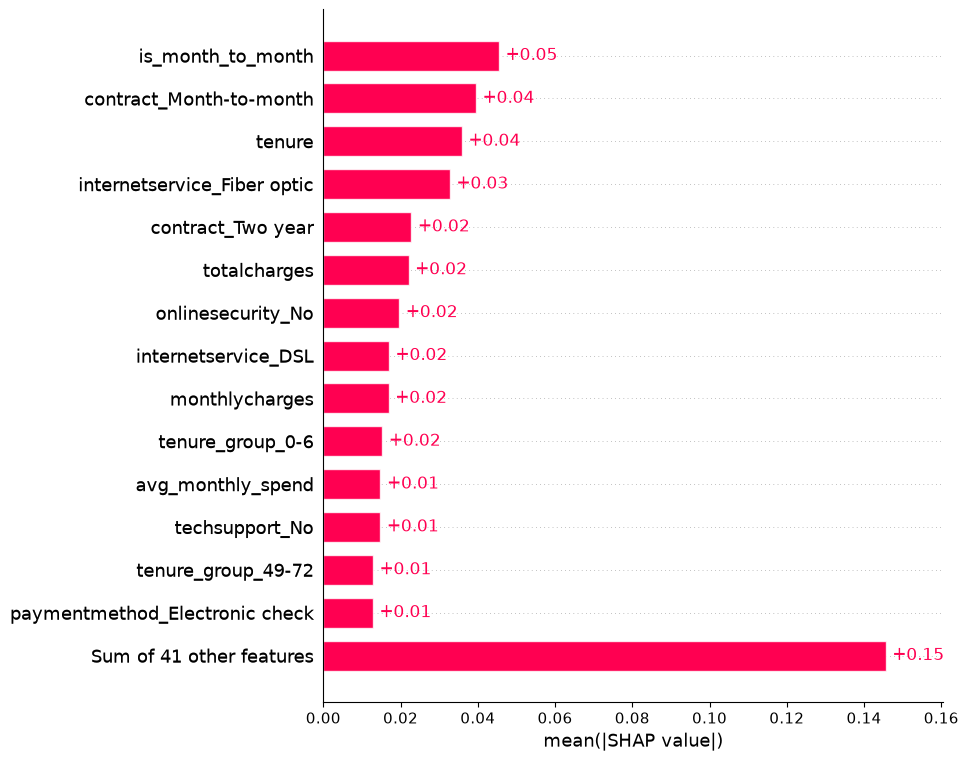

In [36]:
# Global Feature Importance
shap.plots.bar(
    shap_churn,
    max_display=15
)

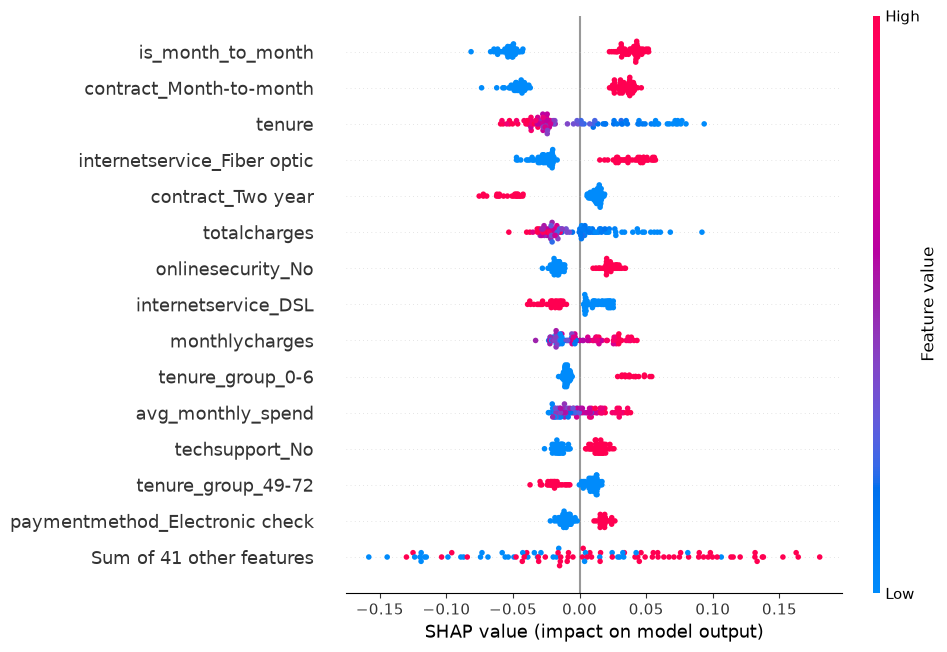

In [37]:
# SHAP Beeswarm Plot
shap.plots.beeswarm(
    shap_churn,
    max_display=15
)

In [38]:
# Explaining ONE custome
customer_index = 0

In [39]:
customer = X.iloc[
    [customer_index]
]

In [40]:
customer.T

,0
gender,Female
seniorcitizen,0
partner,Yes
dependents,No
tenure,1
phoneservice,No
multiplelines,No phone service
internetservice,DSL
onlinesecurity,No
onlinebackup,Yes


In [41]:
# Predicting customer's churn probability
customer_probability = model.predict_proba(
    customer
)[0, 1]

In [42]:
# Printing
print(
    "Churn Probability:",
    round(
        customer_probability * 100,
        2
    ),
    "%"
)

Churn Probability: 69.06 %


In [43]:
customer_prediction = int(
    customer_probability >= threshold
)

In [44]:
# Print
print(
    "Prediction:",
    "Churn"
    if customer_prediction == 1
    else "Stay"
)

Prediction: Churn


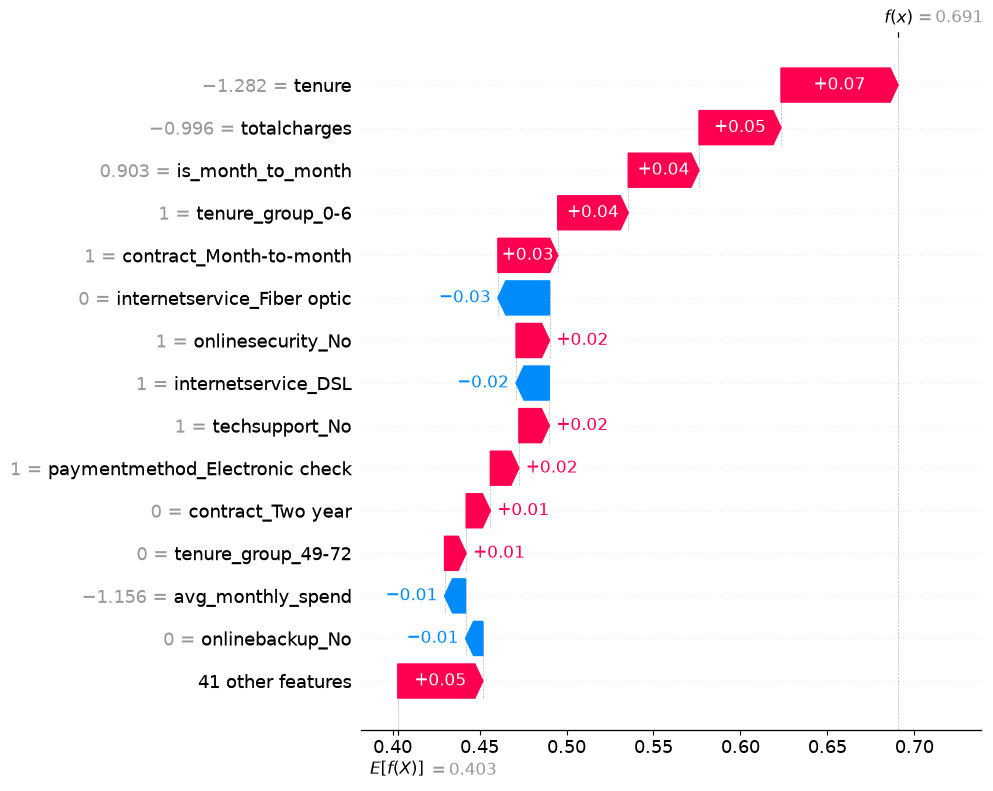

In [45]:
# SHAP Waterfall Plot
shap.plots.waterfall(
    shap_churn[
        customer_index
    ],
    max_display=15
)

In [46]:
# Extracting SHAP values into a table
customer_shap_values = (
    shap_churn[
        customer_index
    ].values
)

In [47]:
# Creating table
explanation_df = pd.DataFrame(
    {
        "feature": clean_feature_names,
        "shap_value": customer_shap_values
    }
)

In [48]:
# Add importance
explanation_df[
    "importance"
] = abs(
    explanation_df["shap_value"]
)

In [49]:
# Sorting
explanation_df = (
    explanation_df
    .sort_values(
        "importance",
        ascending=False
    )
)

In [50]:
explanation_df.head(15)

,feature,shap_value,importance
1,tenure,0.067343,0.067343
3,totalcharges,0.047149,0.047149
7,is_month_to_month,0.040681,0.040681
50,tenure_group_0-6,0.040547,0.040547
41,contract_Month-to-month,0.034414,0.034414
21,internetservice_Fiber optic,-0.029719,0.029719
23,onlinesecurity_No,0.019267,0.019267
20,internetservice_DSL,-0.019167,0.019167
32,techsupport_No,0.017534,0.017534
48,paymentmethod_Electronic check,0.016392,0.016392


In [51]:
# Separating risk-increasing and risk-reducing
risk_increasing = (
    explanation_df[
        explanation_df[
            "shap_value"
        ] > 0
    ]
    .head(5)
)

In [52]:
# Risk reducing
risk_reducing = (
    explanation_df[
        explanation_df[
            "shap_value"
        ] < 0
    ]
    .head(5)
)

In [53]:
risk_reducing = (
    explanation_df[
        explanation_df[
            "shap_value"
        ] < 0
    ]
    .sort_values(
        "shap_value"
    )
    .head(5)
)

In [54]:
risk_increasing

,feature,shap_value,importance
1,tenure,0.067343,0.067343
3,totalcharges,0.047149,0.047149
7,is_month_to_month,0.040681,0.040681
50,tenure_group_0-6,0.040547,0.040547
41,contract_Month-to-month,0.034414,0.034414


In [55]:
risk_reducing

,feature,shap_value,importance
21,internetservice_Fiber optic,-0.029719,0.029719
20,internetservice_DSL,-0.019167,0.019167
5,avg_monthly_spend,-0.012056,0.012056
26,onlinebackup_No,-0.009991,0.009991
28,onlinebackup_Yes,-0.007262,0.007262


In [56]:
# Printing a simple human-readable explanation
print(
    "TOP FACTORS INCREASING CHURN RISK"
)

for _, row in risk_increasing.iterrows():

    print(
        "↑",
        row["feature"],
        round(
            row["shap_value"],
            3
        )
    )

TOP FACTORS INCREASING CHURN RISK
↑ tenure 0.067
↑ totalcharges 0.047
↑ is_month_to_month 0.041
↑ tenure_group_0-6 0.041
↑ contract_Month-to-month 0.034


In [57]:
print(
    "\nTOP FACTORS REDUCING CHURN RISK"
)

for _, row in risk_reducing.iterrows():

    print(
        "↓",
        row["feature"],
        round(
            abs(row["shap_value"]),
            3
        )
    )


TOP FACTORS REDUCING CHURN RISK
↓ internetservice_Fiber optic 0.03
↓ internetservice_DSL 0.019
↓ avg_monthly_spend 0.012
↓ onlinebackup_No 0.01
↓ onlinebackup_Yes 0.007


In [58]:
# Building one reusable function
def explain_customer(
    customer_index,
    X,
    model,
    shap_values,
    feature_names,
    threshold
):

    customer = X.iloc[
        [customer_index]
    ]

    probability = model.predict_proba(
        customer
    )[0, 1]

    prediction = int(
        probability >= threshold
    )

    customer_values = shap_values[
        customer_index
    ].values

    explanation = pd.DataFrame(
        {
            "feature": feature_names,
            "shap_value": customer_values
        }
    )

    explanation[
        "importance"
    ] = abs(
        explanation["shap_value"]
    )

    explanation = explanation.sort_values(
        "importance",
        ascending=False
    )

    print(
        "Churn Probability:",
        round(
            probability * 100,
            2
        ),
        "%"
    )

    print(
        "Prediction:",
        "Churn"
        if prediction == 1
        else "Stay"
    )

    return explanation

In [59]:
explanation = explain_customer(
    0,
    X,
    model,
    shap_churn,
    clean_feature_names,
    threshold
)

Churn Probability: 69.06 %
Prediction: Churn


In [60]:
explanation.head(10)

,feature,shap_value,importance
1,tenure,0.067343,0.067343
3,totalcharges,0.047149,0.047149
7,is_month_to_month,0.040681,0.040681
50,tenure_group_0-6,0.040547,0.040547
41,contract_Month-to-month,0.034414,0.034414
21,internetservice_Fiber optic,-0.029719,0.029719
23,onlinesecurity_No,0.019267,0.019267
20,internetservice_DSL,-0.019167,0.019167
32,techsupport_No,0.017534,0.017534
48,paymentmethod_Electronic check,0.016392,0.016392
